In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import ttest_ind
from scipy.optimize import curve_fit
from matplotlib.collections import PolyCollection

In [2]:
### Fig.5(A)
data25 = pd.read_pickle('G_ripple_data25.pkl')
data25.head(2)

,WinnerID,matched_group,Level,delta_C_ITE
0,W1,M226442,level_0,0.608806
1,W1,M183906,level_0,0.000000


In [3]:
mean_values = data25.groupby('Level')['delta_C_ITE'].mean()
mean_values

Level
level_0    0.113966
level_1    0.039637
level_2    0.015534
level_3    0.010581
Name: delta_C_ITE, dtype: float64

In [4]:
error_bars = data25.groupby('Level')['delta_C_ITE'].apply(lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))
error_bars

Level
level_0    0.011252
level_1    0.002343
level_2    0.001090
level_3    0.001655
Name: delta_C_ITE, dtype: float64

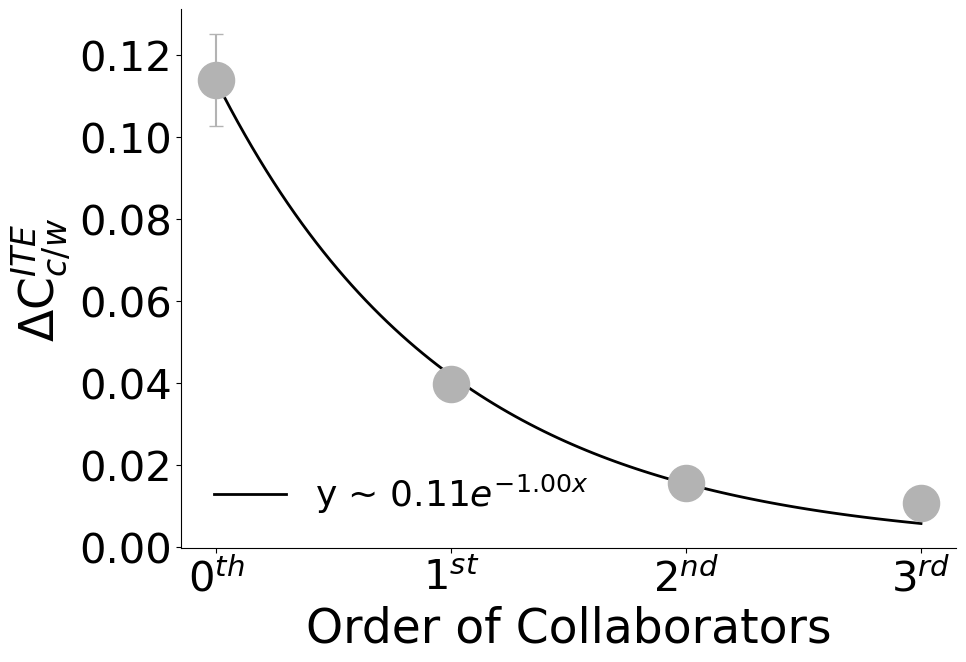

In [5]:
from scipy.optimize import curve_fit
levels = np.array([0, 1, 2, 3])
values = np.array([0.113966, 0.039637, 0.015534, 0.010581])
error_bars = np.array([0.011252, 0.002343, 0.001090, 0.001655])

def exponential_func(x, a, b):
    return a * np.exp(b * x)
params, covariance = curve_fit(exponential_func, levels, values)
a, b = params
x_fit = np.linspace(0, 3, 100)
y_fit = exponential_func(x_fit, a, b)

plt.figure(figsize=(10, 7))
plt.errorbar(levels, values, yerr=error_bars, fmt='o', color='#B3B3B3', markersize=26, capsize=5,capthick=1)
plt.plot(x_fit, y_fit, label=f'y ~ ${a:.2f}  e^{{{b:.2f} x}}$',  color='black', linewidth=2)
plt.yticks(fontsize=30)
plt.xticks([0, 1, 2, 3],["$0^{th}$","$1^{st}$","$2^{nd}$","$3^{rd}$"], fontsize=30)
plt.xlabel("Order of Collaborators", fontsize=34)
plt.ylabel(r"ΔC$^{ITE}_{c/w}$", fontsize=34)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=26, loc='lower left', bbox_to_anchor=(0, 0), frameon=False)
plt.show()

Half-life: 0.6935091923583564
Decay 0-1: 0.6319
Decay 0-2: 0.8645
Decay 0-3: 0.9501


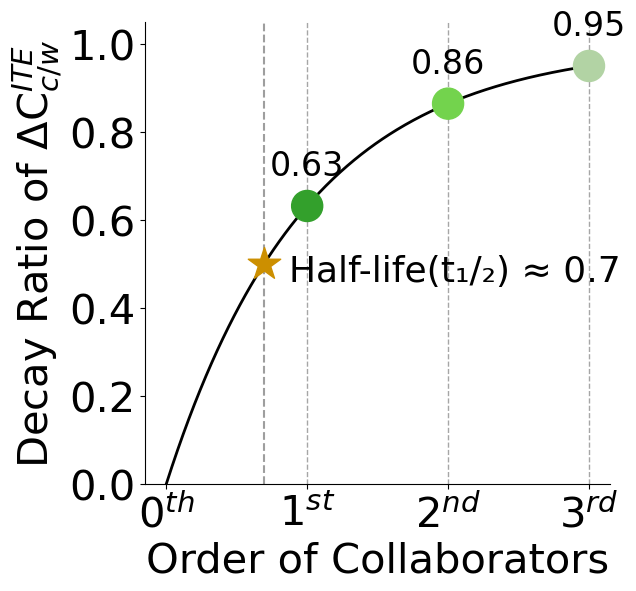

In [6]:
### Fig.5(B)
a = 0.113453
lam = 0.999478
half_life = np.log(2) / lam
def decay_func(x, a, lam):
    return a * np.exp(-lam * x)
def decay_ratio(delta, lam):
    return 1 - np.exp(-lam * delta)
ratios = {
    "0-1": decay_ratio(1, lam),
    "0-2": decay_ratio(2, lam),
    "0-3": decay_ratio(3, lam)}
print("Half-life:", half_life)
for k, v in ratios.items():
    print(f"Decay {k}: {v:.4f}")

plt.figure(figsize=(6, 6))
x_vals = np.linspace(0, 3, 300)
y_vals = decay_ratio(x_vals, lam)
plt.plot(x_vals, y_vals, linewidth=2, color="black")
plt.scatter([1,2,3],[ratios["0-1"], ratios["0-2"], ratios["0-3"]],color=["#33A02C", "#73D34D", "#B2D3A4"], s=500, zorder=5)
plt.text(1, ratios["0-1"] + 0.07, "0.63", color="black", fontsize=24, ha='center')
plt.text(2, ratios["0-2"] + 0.07, "0.86", color="black", fontsize=24, ha='center')
plt.text(3, ratios["0-3"] + 0.07, "0.95", color="black", fontsize=24, ha='center')
plt.axvline(x=half_life, color="#9E9E9E", linestyle="--", linewidth=1.5)
for xc in [1, 2, 3]:
    plt.axvline(x=xc, color="#A6A6A6", linestyle="--", linewidth=1, zorder=1)
x_hl, y_hl = half_life, 0.5
plt.scatter(x_hl, y_hl, color="#CC8F00", s=600, marker="*", zorder=6)
plt.text(half_life+0.18, 0.46, "Half-life(t₁/₂) ≈ 0.7",fontsize=26, color="black")
plt.xlabel("Order of Collaborators", fontsize=30)
plt.ylabel("Decay Ratio of ΔC$^{ITE}_{c/w}$", fontsize=30)
plt.xticks([0, 1, 2, 3],["$0^{th}$","$1^{st}$","$2^{nd}$","$3^{rd}$"],fontsize=30)
plt.yticks(np.linspace(0, 1, 6), fontsize=30)
plt.ylim(0, 1.05)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [7]:
### Fig.5(C)
data26 = pd.read_pickle('G_ripple_data26.pkl')
data26.head(2)

,WinnerID,Coauthor_L1,Coauthor_L2,Coauthor_L3,delta_C_Winner,delta_C_CoauthorL1,delta_C_CoauthorL2,delta_C_CoauthorL3,similarity,strength,discipline_list
0,A1,A478,A7118,A14611,0.230124,0.198424,0.147446,0.217894,0.857492,6,"[Physics, Materials science, Computer science]"
1,A2,A479,A7119,A14611,0.055604,-0.001484,-0.028605,0.217894,0.931817,1,"[Chemistry, Environmental science, History, Me..."


In [8]:
## Baseline
cols = ["delta_C_Winner", "delta_C_CoauthorL1", "delta_C_CoauthorL2", "delta_C_CoauthorL3"]
levels = np.array([0, 1, 2, 3], dtype=float)
fields = ["Chemistry", "Biology", "Physics", "Materials science", "Computer science", "Medicine"]
LIST_COL = "discipline_list"

def exponential_func(x, a, b):
    return a * np.exp(b * x)

results = []

for field in fields:
    df_field = data26.explode(LIST_COL).loc[lambda df: df[LIST_COL] == field].copy()
    y = df_field[cols].mean().values.astype(float)

    params, pcov = curve_fit(exponential_func, levels, y, maxfev=10000)
    b = params[1]
    se_b = np.sqrt(pcov[1, 1])

    t_half = np.log(2) / (-b)
    se_t_half = (np.log(2) / b**2) * se_b

    results.append({"field": field, "t_half": t_half, "se_t_half": se_t_half})

res_df = pd.DataFrame(results)

for _, row in res_df.iterrows():
    print(f"{row['field']}: t₁/₂ = {row['t_half']:.2f} ± {row['se_t_half']:.2f}")

Chemistry: t₁/₂ = 0.67 ± 0.04
Biology: t₁/₂ = 0.72 ± 0.02
Physics: t₁/₂ = 0.63 ± 0.06
Materials science: t₁/₂ = 0.74 ± 0.10
Computer science: t₁/₂ = 0.72 ± 0.05
Medicine: t₁/₂ = 0.69 ± 0.02


In [9]:
## By Topic Similarity
cols = ["delta_C_Winner", "delta_C_CoauthorL1", "delta_C_CoauthorL2", "delta_C_CoauthorL3"]
levels = np.array([0, 1, 2, 3], dtype=float)
fields = ["Chemistry", "Biology", "Physics", "Materials science", "Computer science", "Medicine"]
LIST_COL, SIM_COL = "discipline_list", "similarity"

def exponential_func(x, a, b):
    return a * np.exp(b * x)

results = []

for field in fields:
    df_field = data26.explode(LIST_COL).loc[lambda df: df[LIST_COL] == field].dropna(subset=[SIM_COL]).copy()
    df_field["similarity_group"] = pd.qcut(df_field[SIM_COL], q=[0, .5, 1], labels=["Low", "High"])

    for g in ["Low", "High"]:
        sub = df_field[df_field["similarity_group"] == g]
        y = sub[cols].mean().values.astype(float)

        params, pcov = curve_fit(exponential_func, levels, y, maxfev=10000)
        b = params[1]; se_b = np.sqrt(pcov[1, 1])
        t_half = np.log(2) / (-b)
        se_t_half = (np.log(2) / b**2) * se_b

        results.append({"field": field, "similarity": g, "t_half": t_half, "se_t_half": se_t_half})

res_df = pd.DataFrame(results)

for field in fields:
    print(field)
    for _, row in res_df[res_df["field"] == field].iterrows():
        print(f"  {row['similarity']}: t₁/₂ = {row['t_half']:.2f} ± {row['se_t_half']:.2f}")
    print("")

Chemistry
  Low: t₁/₂ = 0.61 ± 0.04
  High: t₁/₂ = 0.74 ± 0.03

Biology
  Low: t₁/₂ = 0.66 ± 0.03
  High: t₁/₂ = 0.80 ± 0.01

Physics
  Low: t₁/₂ = 0.60 ± 0.09
  High: t₁/₂ = 0.66 ± 0.03

Materials science
  Low: t₁/₂ = 0.73 ± 0.11
  High: t₁/₂ = 0.75 ± 0.10

Computer science
  Low: t₁/₂ = 0.67 ± 0.07
  High: t₁/₂ = 0.78 ± 0.03

Medicine
  Low: t₁/₂ = 0.62 ± 0.04
  High: t₁/₂ = 0.78 ± 0.03



In [10]:
## By Collaboration Strength
cols = ["delta_C_Winner", "delta_C_CoauthorL1", "delta_C_CoauthorL2", "delta_C_CoauthorL3"]
levels = np.array([0, 1, 2, 3], dtype=float)
fields = ["Chemistry", "Biology", "Physics", "Materials science", "Computer science", "Medicine"]
LIST_COL, STR_COL = "discipline_list", "strength"

def exponential_func(x, a, b):
    return a * np.exp(b * x)

results = []

for field in fields:
    df_field = data26.explode(LIST_COL).loc[lambda df: df[LIST_COL] == field].dropna(subset=[STR_COL]).copy()
    df_field["strength_group"] = pd.cut(
        df_field[STR_COL],
        bins=[0, 1.1, df_field[STR_COL].max() + 1],
        labels=["Weak", "Strong"],
        right=False
    )

    for g in ["Weak", "Strong"]:
        sub = df_field[df_field["strength_group"] == g]
        y = sub[cols].mean().values.astype(float)

        params, pcov = curve_fit(exponential_func, levels, y, maxfev=10000)
        b = params[1]; se_b = np.sqrt(pcov[1, 1])

        t_half = np.log(2) / (-b)
        se_t_half = (np.log(2) / b**2) * se_b

        results.append({
            "field": field,
            "strength": g,
            "t_half": t_half,
            "se_t_half": se_t_half
        })

res_df = pd.DataFrame(results)

for field in fields:
    print(field)
    for _, row in res_df[res_df["field"] == field].iterrows():
        print(f"  {row['strength']}: t₁/₂ = {row['t_half']:.2f} ± {row['se_t_half']:.2f}")
    print("")

Chemistry
  Weak: t₁/₂ = 0.63 ± 0.03
  Strong: t₁/₂ = 0.74 ± 0.04

Biology
  Weak: t₁/₂ = 0.66 ± 0.03
  Strong: t₁/₂ = 0.83 ± 0.05

Physics
  Weak: t₁/₂ = 0.65 ± 0.03
  Strong: t₁/₂ = 0.61 ± 0.11

Materials science
  Weak: t₁/₂ = 0.67 ± 0.15
  Strong: t₁/₂ = 0.81 ± 0.10

Computer science
  Weak: t₁/₂ = 0.67 ± 0.03
  Strong: t₁/₂ = 0.82 ± 0.09

Medicine
  Weak: t₁/₂ = 0.64 ± 0.02
  Strong: t₁/₂ = 0.79 ± 0.03

